# 04 — Dimensionality Reduction

Reduce high-dimensional embeddings for clustering and visualization using PCA and UMAP.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

processed_dir = project_root / "data" / "processed"

df = pd.read_csv(processed_dir / "arxiv_clean.csv")
tfidf_matrix = sparse.load_npz(processed_dir / "tfidf_vectors.npz")
minilm_emb = np.load(processed_dir / "minilm_embeddings.npy")
kalm_emb = np.load(processed_dir / "kalm_embeddings.npy")

print(f"Papers: {len(df):,}")
print(f"TF-IDF: {tfidf_matrix.shape}")
print(f"MiniLM: {minilm_emb.shape}")
print(f"KaLM: {kalm_emb.shape}")

Papers: 181,294
TF-IDF: (181294, 27401)
MiniLM: (181294, 384)
KaLM: (181294, 896)


## PCA — Linear Reduction

PCA as a preprocessing step before UMAP. For TF-IDF (27k dims) and KaLM (896 dims), PCA removes redundant dimensions and speeds up UMAP significantly. For MiniLM (384 dims), we skip PCA and feed directly into UMAP.

In [3]:
from sklearn.decomposition import PCA, TruncatedSVD

# TF-IDF is sparse → use TruncatedSVD (PCA for sparse matrices)
print("PCA on TF-IDF (27k → 50)...")
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_pca = svd.fit_transform(tfidf_matrix)
print(f"  Explained variance: {svd.explained_variance_ratio_.sum():.1%}")

# KaLM is dense → use standard PCA
print("PCA on KaLM (896 → 50)...")
pca_kalm = PCA(n_components=50, random_state=42)
kalm_pca = pca_kalm.fit_transform(kalm_emb)
print(f"  Explained variance: {pca_kalm.explained_variance_ratio_.sum():.1%}")

print(f"\nTF-IDF after PCA: {tfidf_pca.shape}")
print(f"MiniLM (no PCA): {minilm_emb.shape}")
print(f"KaLM after PCA: {kalm_pca.shape}")

PCA on TF-IDF (27k → 50)...
  Explained variance: 11.6%
PCA on KaLM (896 → 50)...
  Explained variance: 47.0%

TF-IDF after PCA: (181294, 50)
MiniLM (no PCA): (181294, 384)
KaLM after PCA: (181294, 50)


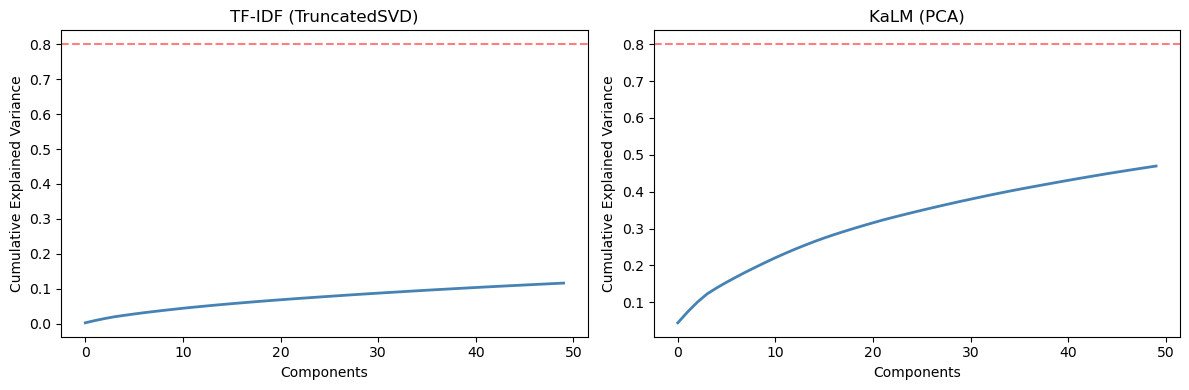

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    np.cumsum(svd.explained_variance_ratio_),
    color="steelblue",
    linewidth=2,
)
axes[0].set_xlabel("Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("TF-IDF (TruncatedSVD)")
axes[0].axhline(y=0.8, color="red", linestyle="--", alpha=0.5)

axes[1].plot(
    np.cumsum(pca_kalm.explained_variance_ratio_),
    color="steelblue",
    linewidth=2,
)
axes[1].set_xlabel("Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("KaLM (PCA)")
axes[1].axhline(y=0.8, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Revised Approach — Skip PCA Where Possible

The PCA results above show that 50 components capture only 11.6% (TF-IDF) and 47% (KaLM) of variance. For an industry-grade pipeline, this loses too much signal.

**Decision:**
- **TF-IDF (27k dims):** Still needs reduction before UMAP, but increase to 500 components for better signal retention
- **MiniLM (384 dims):** Feed directly into UMAP — 384 dimensions is manageable
- **KaLM (896 dims):** Feed directly into UMAP — preserves all learned representations

In [5]:
from sklearn.decomposition import TruncatedSVD

print("TruncatedSVD on TF-IDF (27k → 500)...")
svd = TruncatedSVD(n_components=500, random_state=42)
tfidf_svd = svd.fit_transform(tfidf_matrix)
print(f"  Explained variance: {svd.explained_variance_ratio_.sum():.1%}")
print(f"  Shape: {tfidf_svd.shape}")

TruncatedSVD on TF-IDF (27k → 500)...
  Explained variance: 39.0%
  Shape: (181294, 500)


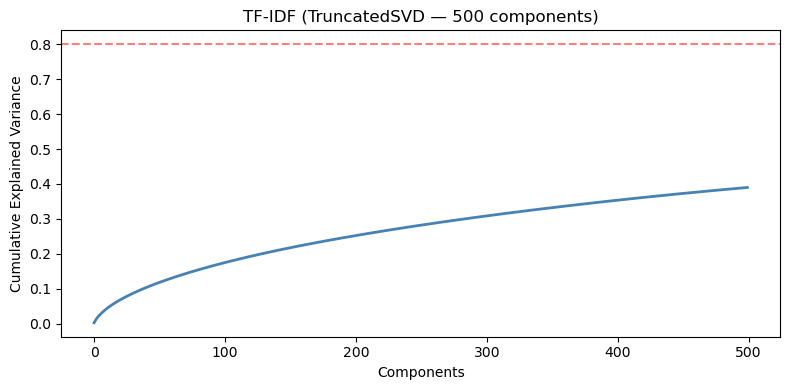

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    np.cumsum(svd.explained_variance_ratio_),
    color="steelblue",
    linewidth=2,
)
ax.set_xlabel("Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("TF-IDF (TruncatedSVD — 500 components)")
ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## PCA / SVD Summary

**TF-IDF:** 500 components capture only 39% of variance. This is a known limitation of TF-IDF — with 27,401 sparse dimensions spread across hundreds of topics, no small linear subspace captures the majority of signal. We proceed with 500 components as a practical tradeoff: more would yield diminishing returns while slowing UMAP.

**MiniLM (384 dims) and KaLM (896 dims):** We feed these directly into UMAP without PCA. Neural embeddings are already dense and compact — every dimension carries learned signal, so linear pre-reduction would discard useful information.

This contrast itself is a finding: TF-IDF's information is thinly spread across thousands of dimensions, while neural models concentrate meaning into a few hundred dense dimensions by design. This is a key motivation for modern embedding approaches.

In [7]:
import umap

print("UMAP 20d on TF-IDF...")
umap_20 = umap.UMAP(n_components=20, n_neighbors=15, min_dist=0.0, random_state=42)
tfidf_umap20 = umap_20.fit_transform(tfidf_svd)
print(f"  Done: {tfidf_umap20.shape}")

print("UMAP 20d on MiniLM...")
umap_20 = umap.UMAP(n_components=20, n_neighbors=15, min_dist=0.0, random_state=42)
minilm_umap20 = umap_20.fit_transform(minilm_emb)
print(f"  Done: {minilm_umap20.shape}")

print("UMAP 20d on KaLM...")
umap_20 = umap.UMAP(n_components=20, n_neighbors=15, min_dist=0.0, random_state=42)
kalm_umap20 = umap_20.fit_transform(kalm_emb)
print(f"  Done: {kalm_umap20.shape}")

UMAP 20d on TF-IDF...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done: (181294, 20)
UMAP 20d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done: (181294, 20)
UMAP 20d on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done: (181294, 20)


In [8]:
print("UMAP 2d on TF-IDF...")
umap_2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
tfidf_umap2 = umap_2.fit_transform(tfidf_svd)
print(f"  Done: {tfidf_umap2.shape}")

print("UMAP 2d on MiniLM...")
umap_2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
minilm_umap2 = umap_2.fit_transform(minilm_emb)
print(f"  Done: {minilm_umap2.shape}")

print("UMAP 2d on KaLM...")
umap_2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
kalm_umap2 = umap_2.fit_transform(kalm_emb)
print(f"  Done: {kalm_umap2.shape}")

UMAP 2d on TF-IDF...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done: (181294, 2)
UMAP 2d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done: (181294, 2)
UMAP 2d on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done: (181294, 2)


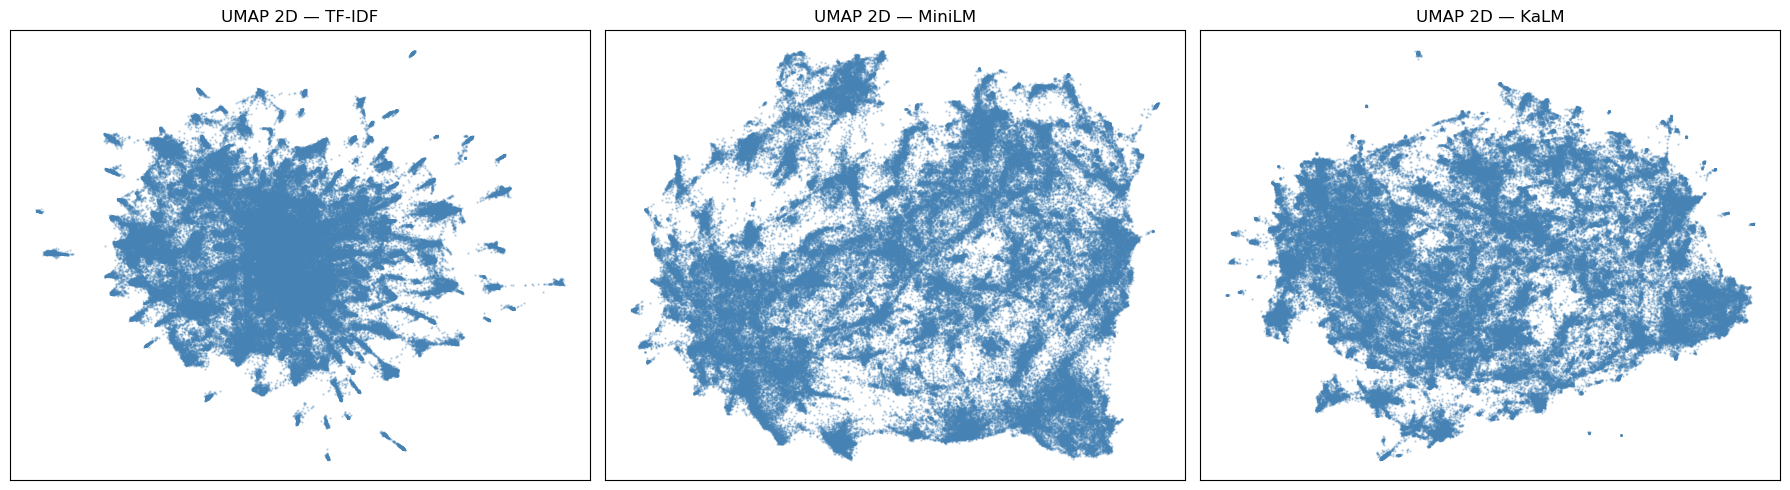

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(
    axes,
    [tfidf_umap2, minilm_umap2, kalm_umap2],
    ["TF-IDF", "MiniLM", "KaLM"],
):
    ax.scatter(
        data[:, 0],
        data[:, 1],
        s=0.5,
        alpha=0.3,
        c="steelblue",
    )
    ax.set_title(f"UMAP 2D — {title}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [10]:
np.save(processed_dir / "tfidf_umap20.npy", tfidf_umap20)
np.save(processed_dir / "tfidf_umap2.npy", tfidf_umap2)
np.save(processed_dir / "minilm_umap20.npy", minilm_umap20)
np.save(processed_dir / "minilm_umap2.npy", minilm_umap2)
np.save(processed_dir / "kalm_umap20.npy", kalm_umap20)
np.save(processed_dir / "kalm_umap2.npy", kalm_umap2)

print("All reduced embeddings saved to data/processed/")

All reduced embeddings saved to data/processed/


In [11]:
print("UMAP 3d on TF-IDF...")
umap_3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
tfidf_umap3 = umap_3.fit_transform(tfidf_svd)

print("UMAP 3d on MiniLM...")
umap_3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
minilm_umap3 = umap_3.fit_transform(minilm_emb)

print("UMAP 3d on KaLM...")
umap_3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
kalm_umap3 = umap_3.fit_transform(kalm_emb)

print("Done.")

UMAP 3d on TF-IDF...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 3d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 3d on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


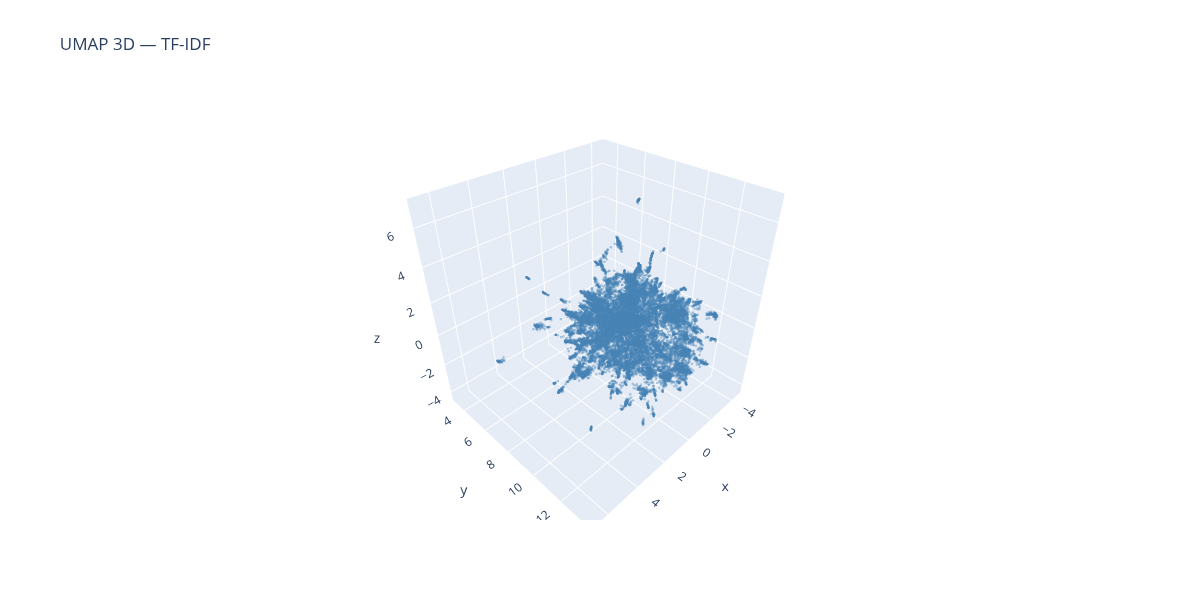

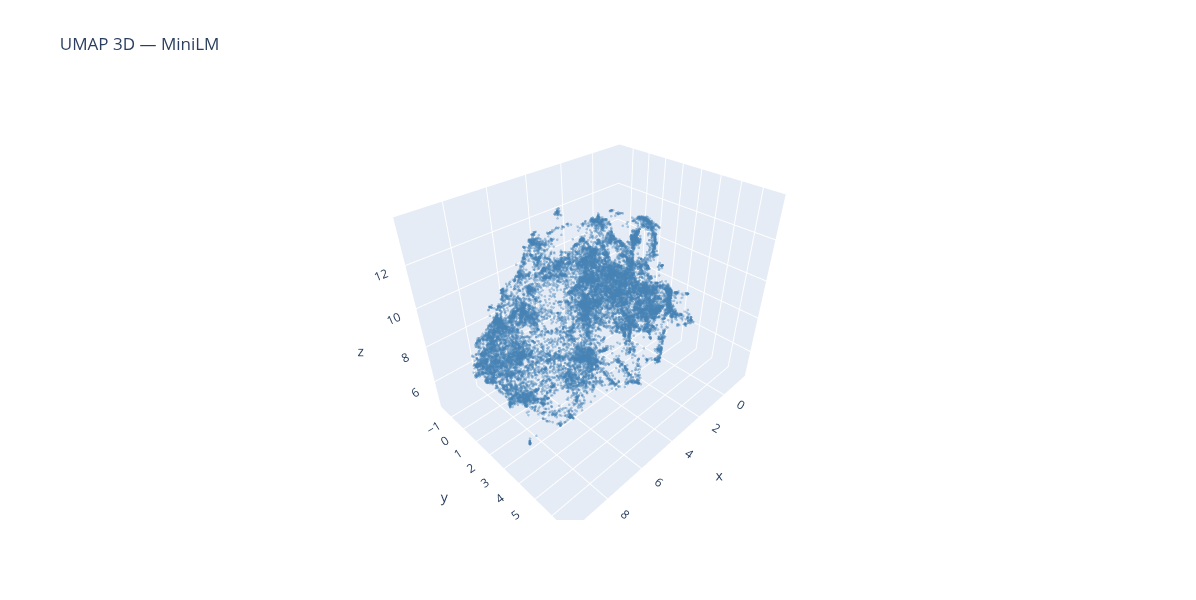

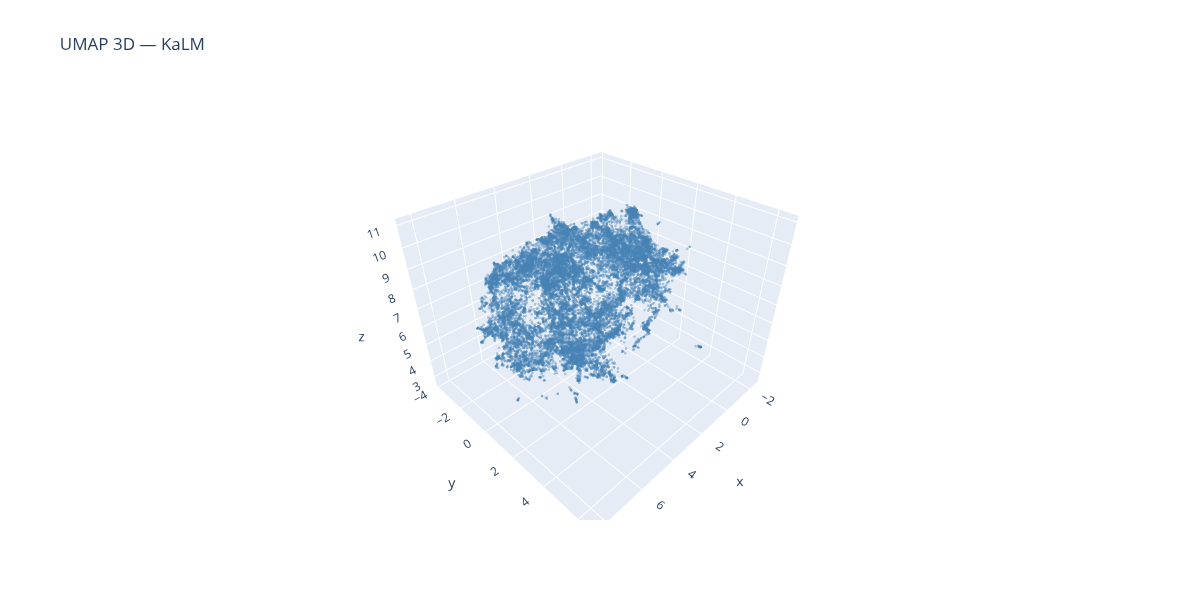

In [ ]:
import plotly.graph_objects as go

# Sample 20k points so Plotly doesn't freeze
sample_idx = np.random.RandomState(42).choice(len(df), size=20000, replace=False)

for data, title in [
    (tfidf_umap3, "TF-IDF"),
    (minilm_umap3, "MiniLM"),
    (kalm_umap3, "KaLM"),
]:
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=data[sample_idx, 0],
                y=data[sample_idx, 1],
                z=data[sample_idx, 2],
                mode="markers",
                marker=dict(size=1.5, opacity=0.4, color="steelblue"),
            )
        ]
    )
    fig.update_layout(
        title=f"UMAP 3D — {title}",
        width=800,
        height=600,
    )
    fig.show()